**实验目标：**

通过本实验，你将深入了解和实践说话人识别技术，并掌握利用声音特征进行有效说话人识别的基本方法，了解不同特征和模型对识别准确率的影响。

实验的核心目标是使用TIMIT数据集来训练一个说话人识别系统，涵盖数据预处理、特征提取、模型训练和评估等关键步骤。


**实验方法：**

**1. 数据预处理和划分(可选)：**
  - 数据集下载地址（4月17日前有效）：https://f.ws59.cn/f/du8yd2536vl
  - 为了方便大家，我们提供了划分好的TIMIT数据集结构，当然你也可以根据需求自行划分该数据集。
  - 为简化难度，我们排除了SA的两个方言句子，并在剩余的8个句子中选取了SX的5个句子和SI的1个句子作为训练集，SI的另外2个句子作为测试集。
  - 该链接下载的数据集只保留了音频文件，完整数据集（包含音频对应文本、标注等信息）可参见备注链接下载。
  
**2. 特征提取：**
  - 学习并实现包括但不限于MFCC特征等特征的提取，探索声音信号的频率和时间特性。
  - 鼓励尝试和比较其他特征提取方法，例如LPCC或声谱图特征，以理解不同特征对识别性能的影响。
  
**3. 模型选择和训练：**
  - 探索并选择适合的分类器和模型进行说话人识别，如GMM、Softmax分类器或深度学习模型。
  - 实现模型训练流程，使用训练集数据训练模型。
  
**4. 评估和分析：**
  - 使用准确率作为主要的评价指标在测试集上评估模型性能。
  - 对比不同特征和模型的性能，分析其对说话人识别准确率的影响。
  - 可视化不同模型的识别结果和错误率，讨论可能的改进方法。

**实验要求：**
  - 1.选择并实现至少一种特征的提取，并鼓励尝试其他特征提取方法。
  - 2.选择并实现至少一种分类器或模型进行说话人识别，并使用准确率评估指标评估其性能。
  - 3.通过实验对比、分析和可视化，撰写详细的实验报告，包括实验目的、实验方法、结果分析和结论。
  - 4.实验报告应以清晰、逻辑性强的形式呈现，图表和结果应清楚明了。

**其他说明：**
  - 实验的最终打分环节会看识别性能，会对原理和实现代码部分做抽查提问，综合评定成绩。
  - 我们**鼓励做原创性探索**，即使性能不是很好，但有创新性、有价值、有意义的探索和尝试会有额外加分。
  - 原数完整据集下载地址：https://drive.google.com/file/d/180mSIiXN9RVDV2Xn1xcWNkMRm5J5MjN4/view?usp=sharing \
    或国内访问地址（4月17日前有效）：https://f.ws59.cn/f/du8xu130kba

## 1. 实验准备

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
import os
import glob
import re
import librosa
import random
import seaborn as sns
import torchaudio
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')


## 2. 数据预处理(加载数据集)

In [2]:

# 数据集基本信息如下
# 方言地区：DR1～DR8
# 性别：F/M
# 说话者ID：3个大写字母+1个阿拉伯数字
# 句子ID：句子类型（SA/SI/SX）+编号
# 详细介绍参见 https://blog.csdn.net/qq_39373179/article/details/103788208

# 上述链接下载的数据集已
TrainDir = r"./Dataset/TEST"
TestDir = r"./Dataset/TRAIN"
## 请在这里写代码加载我们划分好的TIMIT训练集和测试集。或者原始完整版数据集。
# 加载数据集
def load_dataset(root_dir):
    speaker_files = {}
    speaker_ids = []
    
    # 遍历所有方言区
    for dialect_dir in sorted(glob.glob(os.path.join(root_dir, "DR*"))):
        # 遍历每个方言区的所有说话者
        for speaker_dir in sorted(glob.glob(os.path.join(dialect_dir, "*"))):
            speaker_id = os.path.basename(speaker_dir)
            speaker_ids.append(speaker_id)
            
            # 获取说话者的所有音频文件
            wav_files = sorted(glob.glob(os.path.join(speaker_dir, "*.wav")))
            speaker_files[speaker_id] = wav_files
    
    return speaker_files, speaker_ids

# 加载训练集和测试集
train_files, train_speakers = load_dataset(TrainDir)
test_files, test_speakers = load_dataset(TestDir)

print(f"训练集中说话者数量: {len(train_speakers)}")
print(f"测试集中说话者数量: {len(test_speakers)}")

# 显示几个示例
for i, speaker_id in enumerate(list(train_files.keys())[:3]):
    print(f"说话者 {speaker_id} 的训练文件: {[os.path.basename(f) for f in train_files[speaker_id]]}")
    if speaker_id in test_files:
        print(f"说话者 {speaker_id} 的测试文件: {[os.path.basename(f) for f in test_files[speaker_id]]}")
    print()

训练集中说话者数量: 462
测试集中说话者数量: 462
说话者 FCJF0 的训练文件: ['SI1027_.wav', 'SI1657_.wav']
说话者 FCJF0 的测试文件: ['SI648_.wav', 'SX127_.wav', 'SX217_.wav', 'SX307_.wav', 'SX37_.wav', 'SX397_.wav', 'merge_result.wav']

说话者 FDAW0 的训练文件: ['SI1271_.wav', 'SI1406_.wav']
说话者 FDAW0 的测试文件: ['SI2036_.wav', 'SX146_.wav', 'SX236_.wav', 'SX326_.wav', 'SX416_.wav', 'SX56_.wav', 'merge_result.wav']

说话者 FDML0 的训练文件: ['SI1149_.wav', 'SI1779_.wav']
说话者 FDML0 的测试文件: ['SI2075_.wav', 'SX159_.wav', 'SX249_.wav', 'SX339_.wav', 'SX429_.wav', 'SX69_.wav', 'merge_result.wav']



## 3. 特征提取


测试 mfcc 特征提取...
Feature type: mfcc
Number of training samples: 924
Number of test samples: 3234
Number of speakers: 462
Feature shape: torch.Size([200, 40])
Label: 0


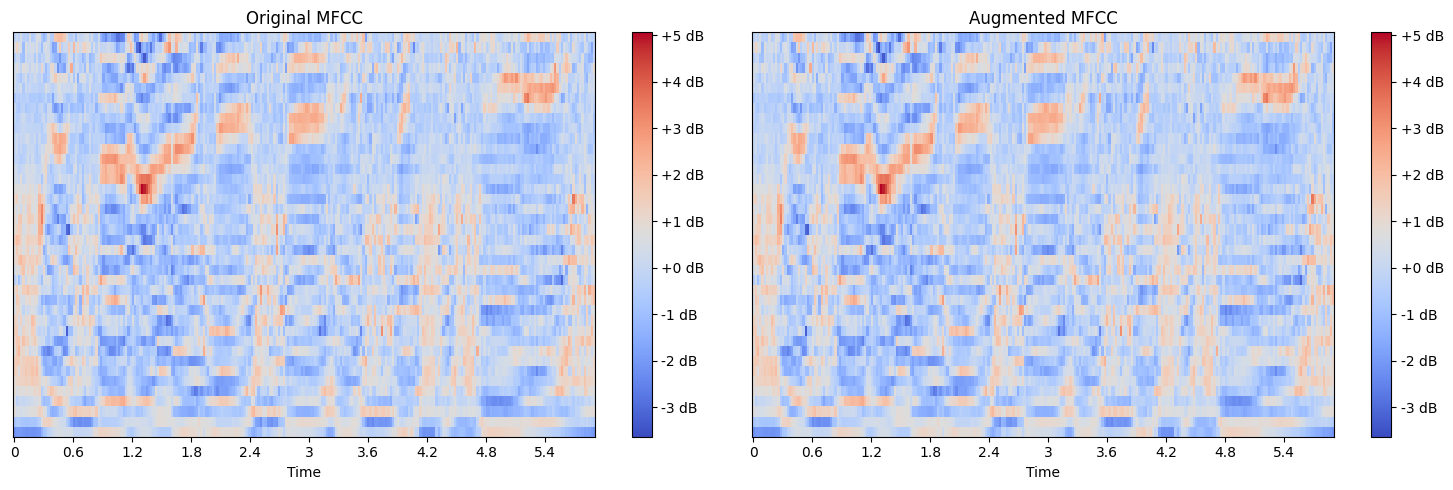


测试 fbank 特征提取...
Feature type: fbank
Number of training samples: 924
Number of test samples: 3234
Number of speakers: 462
Feature shape: torch.Size([200, 80])
Label: 0


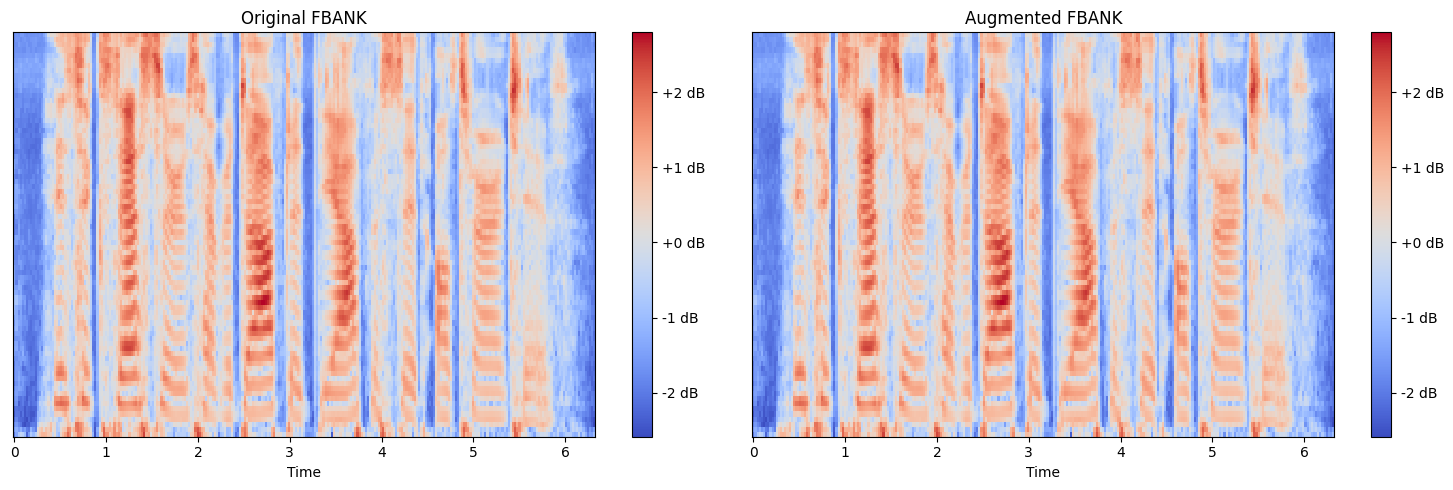


测试 wav2vec2 特征提取...
正在从本地加载wav2vec2模型：./model/wav2vec2-base-960h
尝试替代加载方式...
加载wav2vec2模型失败：name 'init_empty_weights' is not defined
将使用MFCC特征作为后备方案
正在从本地加载wav2vec2模型：./model/wav2vec2-base-960h
尝试替代加载方式...
加载wav2vec2模型失败：name 'init_empty_weights' is not defined
将使用MFCC特征作为后备方案
Feature type: wav2vec2
Number of training samples: 924
Number of test samples: 3234
Number of speakers: 462
Feature shape: torch.Size([200, 40])
Label: 0


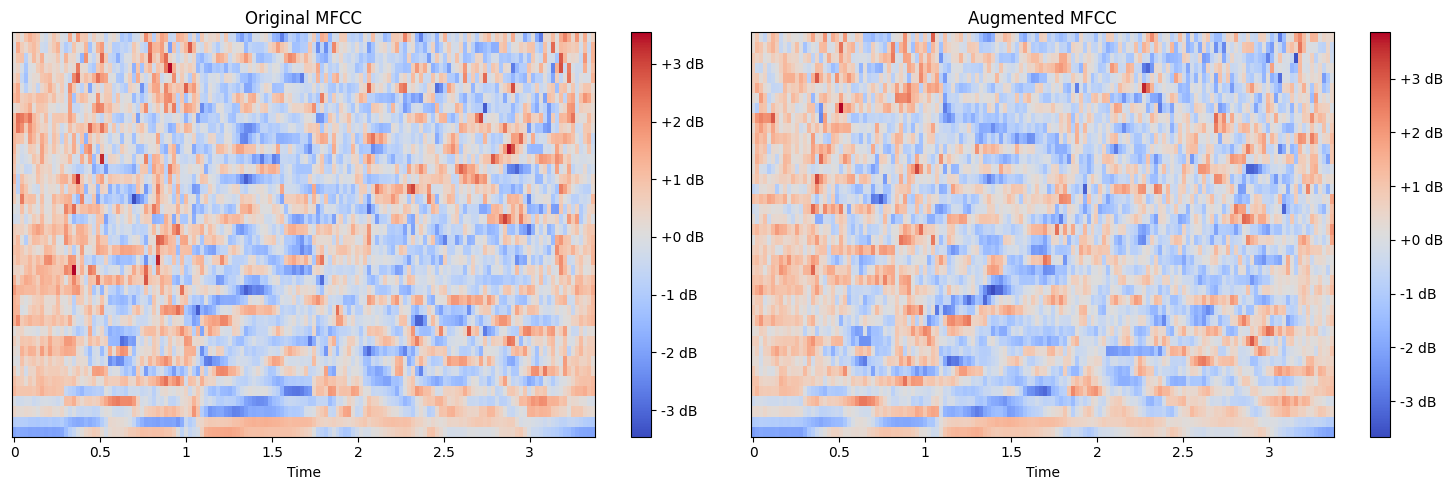

In [3]:
import numpy as np
import torch
from torch.utils.data import Dataset
import librosa
import matplotlib.pyplot as plt
import random
import os
from transformers import Wav2Vec2Processor, Wav2Vec2Model, Wav2Vec2FeatureExtractor
import warnings
warnings.filterwarnings('ignore')

class SpeakerDataset(Dataset):
    def __init__(self, files_dict, feature_type='mfcc', augment=False, model_path=None):
        """初始化数据集
        Args:
            files_dict: 包含说话人音频文件的字典
            feature_type: 特征类型，'mfcc'、'fbank'或'wav2vec2'
            augment: 是否使用数据增强
            model_path: wav2vec2模型的本地路径，例如 './models/wav2vec2-base-960h'
        """
        self.samples = []
        self.speaker_to_id = {}
        self.id_to_speaker = {}
        self.feature_type = feature_type
        self.augment = augment
        
        # 特征提取参数
        self.sample_rate = 16000
        self.n_fft = 512
        self.win_length = 400
        self.hop_length = 160
        self.n_mels = 80
        self.n_mfcc = 40
        
        # 初始化wav2vec2模型（如果需要）
        if feature_type == 'wav2vec2':
            try:
                if model_path is None:
                    raise ValueError("请提供wav2vec2模型的本地路径")
                
                if not os.path.exists(model_path):
                    raise ValueError(f"模型路径不存在：{model_path}")
                
                print(f"正在从本地加载wav2vec2模型：{model_path}")
                
                # 使用特征提取器代替processor
                try:
                    self.feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_path, local_files_only=True, from_tf=True)
                    self.wav2vec2_model = Wav2Vec2Model.from_pretrained(model_path, local_files_only=True, from_tf=True)
                    self.wav2vec2_model.eval()
                    print("成功加载wav2vec2模型")
                except Exception as e:
                    print(f"尝试替代加载方式...")
                    # 尝试直接加载模型，跳过tokenizer
                    config_path = os.path.join(model_path, "config.json")
                    model_path_bin = os.path.join(model_path, "pytorch_model.bin")
                    if os.path.exists(config_path) and os.path.exists(model_path_bin):
                        self.wav2vec2_model = Wav2Vec2Model.from_pretrained(model_path, local_files_only=True, from_tf=True)
                        self.wav2vec2_model.eval()
                        # 使用自定义特征处理
                        self.use_custom_processing = True
                        print("使用自定义特征处理方式加载wav2vec2模型")
                    else:
                        raise ValueError(f"缺少必要的模型文件")
            except Exception as e:
                print(f"加载wav2vec2模型失败：{str(e)}")
                print("将使用MFCC特征作为后备方案")
                self.feature_type = 'mfcc'
        
        # 为每个说话者分配ID
        for i, speaker in enumerate(files_dict.keys()):
            self.speaker_to_id[speaker] = i
            self.id_to_speaker[i] = speaker
            for file_path in files_dict[speaker]:
                self.samples.append((file_path, i))
    
    def apply_augmentation(self, audio, sr):
        """应用数据增强
        Args:
            audio: 音频数据
            sr: 采样率
        Returns:
            增强后的音频数据
        """
        # 1. 速度扰动
        if random.random() < 0.3:
            speed_factor = random.uniform(0.95, 1.05)
            audio = librosa.effects.time_stretch(audio, rate=speed_factor)
        
        # 2. 音量扰动
        if random.random() < 0.3:
            volume_factor = random.uniform(0.7, 1.3)
            audio = audio * volume_factor
            
        # 3. 添加高斯噪声
        if random.random() < 0.2:
            noise_factor = random.uniform(0.0005, 0.005)
            noise = np.random.randn(len(audio)) * noise_factor
            audio = audio + noise
            
        # 4. 添加混响效果
        if random.random() < 0.2:
            reverb_len = int(sr * 0.05)
            decay = np.exp(-np.linspace(0, 3, reverb_len))
            impulse_response = decay * (np.random.rand(reverb_len) * 1.5 - 0.75)
            audio = np.convolve(audio, impulse_response, mode='full')[:len(audio)]
            
        return audio

    def extract_wav2vec2_features(self, audio, sr):
        """提取wav2vec2特征
        Args:
            audio: 音频数据
            sr: 采样率
        Returns:
            wav2vec2特征
        """
        try:
            with torch.no_grad():
                # 确保音频采样率正确
                if sr != self.sample_rate:
                    audio = librosa.resample(audio, orig_sr=sr, target_sr=self.sample_rate)
                
                # 处理音频
                if hasattr(self, 'use_custom_processing') and self.use_custom_processing:
                    # 使用自定义预处理
                    input_values = torch.tensor(audio).unsqueeze(0)
                    outputs = self.wav2vec2_model(input_values)
                else:
                    # 使用特征提取器
                    inputs = self.feature_extractor(audio, sampling_rate=sr, return_tensors="pt")
                    outputs = self.wav2vec2_model(**inputs)
                
                features = outputs.last_hidden_state.squeeze(0).numpy()
                
                # 特征标准化
                features = (features - np.mean(features, axis=0, keepdims=True)) / \
                          (np.std(features, axis=0, keepdims=True) + 1e-8)
                
                return features  # 返回形状为 [T, F]
        except Exception as e:
            print(f"Wav2Vec2特征提取失败：{str(e)}")
            return None

    def extract_features(self, audio, sr):
        """提取特定类型的特征
        Args:
            audio: 音频数据
            sr: 采样率
        Returns:
            features: 选定类型的特征
        """
        # 提取wav2vec2特征
        if self.feature_type == 'wav2vec2':
            features = self.extract_wav2vec2_features(audio, sr)
            if features is not None:
                return features
            # 如果wav2vec2提取失败，将回退到MFCC特征
            print("Wav2Vec2特征提取失败，回退到MFCC特征")
            self.feature_type = 'mfcc'
        
        # 计算STFT
        D = librosa.stft(audio, 
                         n_fft=self.n_fft,
                         win_length=self.win_length,
                         hop_length=self.hop_length,
                         window='hamming')
        power_spec = np.abs(D) ** 2
        
        # 根据特征类型提取对应特征
        if self.feature_type == 'mfcc':
            # 提取MFCC特征
            features = librosa.feature.mfcc(y=audio,
                                           sr=sr,
                                           n_mfcc=self.n_mfcc,
                                           n_fft=self.n_fft,
                                           win_length=self.win_length,
                                           hop_length=self.hop_length)
        else:  # fbank
            # 提取Fbank特征
            mel_basis = librosa.filters.mel(sr=sr,
                                          n_fft=self.n_fft,
                                          n_mels=self.n_mels,
                                          fmin=0,
                                          fmax=sr/2)
            features = np.dot(mel_basis, power_spec)
            features = np.log(features + 1e-8)
        
        # 特征标准化
        features = (features - np.mean(features, axis=1, keepdims=True)) / \
                   (np.std(features, axis=1, keepdims=True) + 1e-8)
        
        return features
    
    def process_features(self, feature, max_len=200):
        """处理特征，统一长度
        Args:
            feature: 输入特征
            max_len: 最大长度
        Returns:
            处理后的特征
        """
        # 处理wav2vec2特征（已经是[T, F]形状）
        if self.feature_type == 'wav2vec2':
            if feature.shape[0] > max_len:
                feature = feature[:max_len, :]
            else:
                pad_width = ((0, max_len - feature.shape[0]), (0, 0))
                feature = np.pad(feature, pad_width, mode='constant')
            return feature
        
        # 处理MFCC和Fbank特征（[F, T]形状）
        if feature.shape[1] > max_len:
            feature = feature[:, :max_len]
        else:
            pad_width = ((0, 0), (0, max_len - feature.shape[1]))
            feature = np.pad(feature, pad_width, mode='constant')
        
        # 转置特征矩阵，从[F, T]变为[T, F]
        feature = feature.T
        return feature
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        file_path, speaker_id = self.samples[idx]
        
        # 1. 加载音频
        audio, sr = librosa.load(file_path, sr=self.sample_rate)
        
        # 2. 数据增强
        if self.augment:
            audio = self.apply_augmentation(audio, sr)
        
        # 3. 特征提取
        feature = self.extract_features(audio, sr)
        
        # 4. 处理特征
        feature = self.process_features(feature)
        
        return torch.tensor(feature, dtype=torch.float32), torch.tensor(speaker_id, dtype=torch.long)
    
    def get_n_speakers(self):
        """获取说话人数量"""
        return len(self.speaker_to_id)

def visualize_augmentation_comparison(dataset, idx):
    """可视化增强前后的对比"""
    file_path, speaker_id = dataset.samples[idx]
    
    # 加载原始音频
    audio_original, sr = librosa.load(file_path, sr=dataset.sample_rate)
    feature_original = dataset.extract_features(audio_original, sr)
    
    # 应用增强
    audio_augmented = dataset.apply_augmentation(audio_original.copy(), sr)
    feature_augmented = dataset.extract_features(audio_augmented, sr)
    
    # 创建图像
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 显示原始特征
    if dataset.feature_type == 'wav2vec2':
        # wav2vec2特征已经是[T, F]格式
        im1 = librosa.display.specshow(feature_original.T, ax=axes[0], x_axis='time')
    else:
        # MFCC和FBANK特征是[F, T]格式
        im1 = librosa.display.specshow(feature_original, ax=axes[0], x_axis='time')
    
    axes[0].set_title(f'Original {dataset.feature_type.upper()}')
    fig.colorbar(im1, ax=axes[0], format='%+2.0f dB')
    
    # 显示增强后的特征
    if dataset.feature_type == 'wav2vec2':
        # wav2vec2特征已经是[T, F]格式
        im2 = librosa.display.specshow(feature_augmented.T, ax=axes[1], x_axis='time')
    else:
        # MFCC和FBANK特征是[F, T]格式
        im2 = librosa.display.specshow(feature_augmented, ax=axes[1], x_axis='time')
    
    axes[1].set_title(f'Augmented {dataset.feature_type.upper()}')
    fig.colorbar(im2, ax=axes[1], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()

# 创建一个简单的测试数据集用于检验代码是否正常运行
def create_test_dataset():
    import tempfile
    import soundfile as sf
    
    # 创建临时目录
    temp_dir = tempfile.mkdtemp()
    
    # 生成一些测试音频文件
    files_dict = {}
    for speaker_id in range(3):
        speaker_name = f"speaker_{speaker_id}"
        files_dict[speaker_name] = []
        
        for i in range(2):
            # 生成随机音频
            audio = np.random.randn(16000)  # 1秒的音频
            file_path = os.path.join(temp_dir, f"{speaker_name}_{i}.wav")
            sf.write(file_path, audio, 16000)
            files_dict[speaker_name].append(file_path)
    
    return files_dict

# 测试代码
try:
    # 尝试使用train_files，如果未定义则使用测试数据
    if 'train_files' not in globals():
        print("创建测试数据集...")
        train_files = create_test_dataset()
        test_files = train_files
    
    # 设置wav2vec2模型的本地路径
    model_path = "./model/wav2vec2-base-960h"  # 替换为您的本地模型路径
    
    # 创建数据集实例
    feature_types = ['mfcc', 'fbank', 'wav2vec2']
    for feature_type in feature_types:
        try:
            print(f"\n测试 {feature_type} 特征提取...")
            train_dataset = SpeakerDataset(train_files, 
                                         feature_type=feature_type, 
                                         augment=True,
                                         model_path=model_path)
            test_dataset = SpeakerDataset(test_files, 
                                        feature_type=feature_type, 
                                        augment=False,
                                        model_path=model_path)
    
            print(f"Feature type: {feature_type}")
            print(f"Number of training samples: {len(train_dataset)}")
            print(f"Number of test samples: {len(test_dataset)}")
            print(f"Number of speakers: {train_dataset.get_n_speakers()}")
            
            # 测试特征提取
            features, label = train_dataset[0]
            print(f"Feature shape: {features.shape}")
            print(f"Label: {label}")
            
            # 随机选择一个样本进行可视化对比
            random_idx = random.randint(0, len(train_dataset)-1)
            visualize_augmentation_comparison(train_dataset, random_idx)
            
        except Exception as e:
            print(f"{feature_type}特征提取测试失败：{str(e)}")
            import traceback
            traceback.print_exc()
except Exception as e:
    print(f"测试失败：{str(e)}")
    import traceback
    traceback.print_exc()

## 4.2定义模型类

### 4.2.1EcapaTDNN

In [6]:
class EcapaTDNN(nn.Module):
    def __init__(self, input_size=40, channels=512, embd_dim=192, n_speakers=None, feature_type='mfcc', dropout_rate=0.2):
        super(EcapaTDNN, self).__init__()
        
        # 保存特征类型信息
        self.feature_type = feature_type
        
        # Initial TDNN layer
        self.conv1 = nn.Conv1d(input_size, channels, 5, padding=2)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(channels)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # SE-Res2Net blocks
        self.layer1 = SERes2NetBlock(channels, channels, kernel_size=3, dilation=2, dropout_rate=dropout_rate)
        self.layer2 = SERes2NetBlock(channels, channels, kernel_size=3, dilation=3, dropout_rate=dropout_rate)
        self.layer3 = SERes2NetBlock(channels, channels, kernel_size=3, dilation=4, dropout_rate=dropout_rate)
        
        # Multi-layer feature aggregation
        self.mfa = nn.Conv1d(channels*3, channels, 1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # Attentive Statistics Pooling
        self.asp = AttentiveStatisticsPooling(channels)
        self.bn3 = nn.BatchNorm1d(channels*2)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(channels*2, embd_dim)
        
        # Speaker classifier
        if n_speakers is not None:
            self.classifier = nn.Linear(embd_dim, n_speakers)
        else:
            self.classifier = None

    def forward(self, x):
        # Input shape: [B, T, F]
        x = x.transpose(1, 2)  # [B, F, T]
        
        # Initial TDNN
        x = self.conv1(x)
        x = self.relu(x)
        x = self.bn1(x)
        x = self.dropout1(x)
        
        # SE-Res2Net blocks
        layer1_out = self.layer1(x)
        layer2_out = self.layer2(layer1_out)
        layer3_out = self.layer3(layer2_out)
        
        # Multi-layer feature aggregation
        concat = torch.cat([layer1_out, layer2_out, layer3_out], dim=1)
        x = self.mfa(concat)
        x = self.relu(x)
        x = self.bn2(x)
        x = self.dropout2(x)
        
        # Attentive Statistics Pooling
        x = self.asp(x)
        x = self.bn3(x)
        x = self.dropout3(x)
        
        # Final embedding
        features = self.fc(x)
        
        if self.classifier is not None:
            logits = self.classifier(features)
            # 返回与AAMLoss匹配的字典
            return {
                'features': features,
                'logits': logits
            }
        else:
            return {'features': features}

class SERes2NetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, scale=8, se_channels=128, dropout_rate=0.2):
        super(SERes2NetBlock, self).__init__()
        width = out_channels // scale
        self.width = width
        self.nums = scale - 1
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, 1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.convs = nn.ModuleList([
            nn.Conv1d(width, width, kernel_size, dilation=dilation, 
                     padding=dilation*(kernel_size-1)//2)
            for i in range(self.nums)
        ])
        self.bns = nn.ModuleList([
            nn.BatchNorm1d(width) for i in range(self.nums)
        ])
        self.dropouts = nn.ModuleList([
            nn.Dropout(dropout_rate) for i in range(self.nums)
        ])
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, 1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # SE block
        self.se = SEModule(out_channels, se_channels, dropout_rate)
        
        # Shortcut
        self.shortcut = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.bn_shortcut = nn.BatchNorm1d(out_channels) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        residual = self.bn_shortcut(self.shortcut(x))
        
        # First conv
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout1(out)
        
        # Res2Net block
        spx = torch.split(out, self.width, 1)
        for i in range(self.nums):
            if i==0:
                sp = spx[i]
            else:
                sp = sp + spx[i]
            sp = self.convs[i](sp)
            sp = self.bns[i](sp)
            sp = self.relu1(sp)
            sp = self.dropouts[i](sp)
            if i==0:
                out = sp
            else:
                out = torch.cat((out, sp), 1)
        out = torch.cat((out, spx[self.nums]), 1)
        
        # Second conv
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        
        # SE block
        out = self.se(out)
        
        return out + residual

class AttentiveStatisticsPooling(nn.Module):
    def __init__(self, channels, attention_channels=128, dropout_rate=0.1):
        super(AttentiveStatisticsPooling, self).__init__()
        self.attention = nn.Sequential(
            nn.Conv1d(channels, attention_channels, 1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.BatchNorm1d(attention_channels),
            nn.Conv1d(attention_channels, channels, 1),
            nn.Softmax(dim=2)
        )

    def forward(self, x):
        # Calculate attention weights
        attn = self.attention(x)
        
        # Apply attention
        weighted = x * attn
        
        # Calculate statistics
        mean = torch.sum(weighted, dim=2)
        var = torch.sum(weighted * x, dim=2) - mean * mean
        
        # Concatenate mean and standard deviation
        std = torch.sqrt(var.clamp(min=1e-9))
        return torch.cat([mean, std], dim=1)

class SEModule(nn.Module):
    def __init__(self, channels, bottleneck=128, dropout_rate=0.1):
        super(SEModule, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(channels, bottleneck)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(bottleneck, channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        batch_size, channels, _ = x.size()
        y = self.avg_pool(x).view(batch_size, channels)
        y = self.relu(self.fc1(y))
        y = self.dropout(y)
        y = self.sigmoid(self.fc2(y))
        y = y.view(batch_size, channels, 1)
        return x * y


### 4.2.2 TDNN

In [5]:
class TDNN(nn.Module):
    def __init__(self, input_size=40, channels=512, embd_dim=192, n_speakers=None, feature_type='mfcc', dropout_rate=0.2):
        super(TDNN, self).__init__()
        
        # 保存特征类型信息（与EcapaTDNN保持一致的接口）
        self.feature_type = feature_type
        
        # 第一层TDNN
        self.frame1 = nn.Conv1d(input_size, channels, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # 第二层TDNN（dilation=2）
        self.frame2 = nn.Conv1d(channels, channels, kernel_size=3, dilation=2, padding=2)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # 第三层TDNN（dilation=3）
        self.frame3 = nn.Conv1d(channels, channels, kernel_size=3, dilation=3, padding=3)
        self.bn3 = nn.BatchNorm1d(channels)
        self.dropout3 = nn.Dropout(dropout_rate)
        
        # 第四层TDNN
        self.frame4 = nn.Conv1d(channels, channels, kernel_size=1)
        self.bn4 = nn.BatchNorm1d(channels)
        self.dropout4 = nn.Dropout(dropout_rate)
        
        # 第五层TDNN
        self.frame5 = nn.Conv1d(channels, channels, kernel_size=1)
        self.bn5 = nn.BatchNorm1d(channels)
        self.dropout5 = nn.Dropout(dropout_rate)
        
        # 使用与EcapaTDNN相同的AttentiveStatisticsPooling
        self.asp = AttentiveStatisticsPooling(channels, attention_channels=128, dropout_rate=dropout_rate)
        self.bn_asp = nn.BatchNorm1d(channels * 2)
        self.dropout_asp = nn.Dropout(dropout_rate)
        
        # 最终嵌入层
        self.fc = nn.Linear(channels * 2, embd_dim)
        self.bn_fc = nn.BatchNorm1d(embd_dim)
        self.dropout_fc = nn.Dropout(dropout_rate)
        
        # 分类器
        if n_speakers is not None:
            self.classifier = nn.Linear(embd_dim, n_speakers)
        else:
            self.classifier = None

    def forward(self, x):
        # 输入形状: [B, T, F]
        x = x.transpose(1, 2)  # [B, F, T]
        
        # TDNN层
        x = self.frame1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        
        x = self.frame2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        
        x = self.frame3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout3(x)
        
        x = self.frame4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.dropout4(x)
        
        x = self.frame5(x)
        x = self.bn5(x)
        x = self.relu(x)
        x = self.dropout5(x)
        
        # 注意力统计池化
        x = self.asp(x)
        x = self.bn_asp(x)
        x = self.dropout_asp(x)
        
        # 最终嵌入
        features = self.fc(x)
        features = self.bn_fc(features)
        features = self.dropout_fc(features)
        
        # 与EcapaTDNN保持相同的返回格式
        if self.classifier is not None:
            logits = self.classifier(features)
            return {
                'features': features,
                'logits': logits
            }
        else:
            return {'features': features}

### 4.2.3 CAMPPlus

In [6]:
# 添加CAMPPlus模型
import math
from collections import OrderedDict

import torch
import torch.nn.functional as F
import torch.utils.checkpoint as cp
from torch import nn


def get_nonlinear(config_str, channels):
    nonlinear = nn.Sequential()
    for name in config_str.split('-'):
        if name == 'relu':
            nonlinear.add_module('relu', nn.ReLU(inplace=True))
        elif name == 'prelu':
            nonlinear.add_module('prelu', nn.PReLU(channels))
        elif name == 'batchnorm':
            nonlinear.add_module('batchnorm', nn.BatchNorm1d(channels))
        elif name == 'batchnorm_':
            nonlinear.add_module('batchnorm',
                                 nn.BatchNorm1d(channels, affine=False))
        else:
            raise ValueError('Unexpected module ({}).'.format(name))
    return nonlinear


def statistics_pooling(x, dim=-1, keepdim=False, unbiased=True, eps=1e-2):
    mean = x.mean(dim=dim)
    std = x.std(dim=dim, unbiased=unbiased)
    stats = torch.cat([mean, std], dim=-1)
    if keepdim:
        stats = stats.unsqueeze(dim=dim)
    return stats


class StatsPool(nn.Module):
    def forward(self, x):
        return statistics_pooling(x)


class TDNNLayer(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 stride=1,
                 padding=0,
                 dilation=1,
                 bias=False,
                 config_str='batchnorm-relu'):
        super(TDNNLayer, self).__init__()
        if padding < 0:
            assert kernel_size % 2 == 1, 'Expect equal paddings, but got even kernel size ({})'.format(
                kernel_size)
            padding = (kernel_size - 1) // 2 * dilation
        self.linear = nn.Conv1d(in_channels,
                                out_channels,
                                kernel_size,
                                stride=stride,
                                padding=padding,
                                dilation=dilation,
                                bias=bias)
        self.nonlinear = get_nonlinear(config_str, out_channels)

    def forward(self, x):
        x = self.linear(x)
        x = self.nonlinear(x)
        return x


class CAMLayer(nn.Module):
    def __init__(self,
                 bn_channels,
                 out_channels,
                 kernel_size,
                 stride,
                 padding,
                 dilation,
                 bias,
                 reduction=2):
        super(CAMLayer, self).__init__()
        self.linear_local = nn.Conv1d(bn_channels,
                                      out_channels,
                                      kernel_size,
                                      stride=stride,
                                      padding=padding,
                                      dilation=dilation,
                                      bias=bias)
        self.linear1 = nn.Conv1d(bn_channels, bn_channels // reduction, 1)
        self.relu = nn.ReLU(inplace=True)
        self.linear2 = nn.Conv1d(bn_channels // reduction, out_channels, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.linear_local(x)
        context = x.mean(-1, keepdim=True) + self.seg_pooling(x)
        context = self.relu(self.linear1(context))
        m = self.sigmoid(self.linear2(context))
        return y * m

    def seg_pooling(self, x, seg_len=100, stype='avg'):
        if stype == 'avg':
            seg = F.avg_pool1d(x, kernel_size=seg_len, stride=seg_len, ceil_mode=True)
        elif stype == 'max':
            seg = F.max_pool1d(x, kernel_size=seg_len, stride=seg_len, ceil_mode=True)
        else:
            raise ValueError('Wrong segment pooling type.')
        shape = seg.shape
        seg = seg.unsqueeze(-1).expand(*shape, seg_len).reshape(*shape[:-1], -1)
        seg = seg[..., :x.shape[-1]]
        return seg


class CAMDenseTDNNLayer(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 bn_channels,
                 kernel_size,
                 stride=1,
                 dilation=1,
                 bias=False,
                 config_str='batchnorm-relu',
                 memory_efficient=False):
        super(CAMDenseTDNNLayer, self).__init__()
        assert kernel_size % 2 == 1, 'Expect equal paddings, but got even kernel size ({})'.format(
            kernel_size)
        padding = (kernel_size - 1) // 2 * dilation
        self.memory_efficient = memory_efficient
        self.nonlinear1 = get_nonlinear(config_str, in_channels)
        self.linear1 = nn.Conv1d(in_channels, bn_channels, 1, bias=False)
        self.nonlinear2 = get_nonlinear(config_str, bn_channels)
        self.cam_layer = CAMLayer(bn_channels,
                                  out_channels,
                                  kernel_size,
                                  stride=stride,
                                  padding=padding,
                                  dilation=dilation,
                                  bias=bias)

    def bn_function(self, x):
        return self.linear1(self.nonlinear1(x))

    def forward(self, x):
        if self.training and self.memory_efficient:
            x = cp.checkpoint(self.bn_function, x, use_reentrant=False)
        else:
            x = self.bn_function(x)
        x = self.cam_layer(self.nonlinear2(x))
        return x


class CAMDenseTDNNBlock(nn.ModuleList):
    def __init__(self,
                 num_layers,
                 in_channels,
                 out_channels,
                 bn_channels,
                 kernel_size,
                 stride=1,
                 dilation=1,
                 bias=False,
                 config_str='batchnorm-relu',
                 memory_efficient=False):
        super(CAMDenseTDNNBlock, self).__init__()
        for i in range(num_layers):
            layer = CAMDenseTDNNLayer(in_channels=in_channels + i * out_channels,
                                      out_channels=out_channels,
                                      bn_channels=bn_channels,
                                      kernel_size=kernel_size,
                                      stride=stride,
                                      dilation=dilation,
                                      bias=bias,
                                      config_str=config_str,
                                      memory_efficient=memory_efficient)
            self.add_module('tdnnd%d' % (i + 1), layer)

    def forward(self, x):
        for layer in self:
            x = torch.cat([x, layer(x)], dim=1)
        return x


class TransitLayer(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 bias=True,
                 config_str='batchnorm-relu'):
        super(TransitLayer, self).__init__()
        self.nonlinear = get_nonlinear(config_str, in_channels)
        self.linear = nn.Conv1d(in_channels, out_channels, 1, bias=bias)

    def forward(self, x):
        x = self.nonlinear(x)
        x = self.linear(x)
        return x


class DenseLayer(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 bias=False,
                 config_str='batchnorm-relu'):
        super(DenseLayer, self).__init__()
        self.linear = nn.Conv1d(in_channels, out_channels, 1, bias=bias)
        self.nonlinear = get_nonlinear(config_str, out_channels)

    def forward(self, x):
        if len(x.shape) == 2:
            x = self.linear(x.unsqueeze(dim=-1)).squeeze(dim=-1)
        else:
            x = self.linear(x)
        x = self.nonlinear(x)
        return x


class BasicResBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes,
                               planes,
                               kernel_size=3,
                               stride=(stride, 1),
                               padding=1,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes,
                               planes,
                               kernel_size=3,
                               stride=1,
                               padding=1,
                               bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes,
                          self.expansion * planes,
                          kernel_size=1,
                          stride=(stride, 1),
                          bias=False),
                nn.BatchNorm2d(self.expansion * planes))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class FCM(nn.Module):
    def __init__(self,
                 block=BasicResBlock,
                 num_blocks=[2, 2],
                 m_channels=32,
                 feat_dim=80):
        super(FCM, self).__init__()
        self.in_planes = m_channels
        self.conv1 = nn.Conv2d(1, m_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(m_channels)

        self.layer1 = self._make_layer(block, m_channels, num_blocks[0], stride=2)
        self.layer2 = self._make_layer(block, m_channels, num_blocks[0], stride=2)

        self.conv2 = nn.Conv2d(m_channels, m_channels, kernel_size=3, stride=(2, 1), padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(m_channels)
        self.out_channels = m_channels * (math.ceil(feat_dim / 8))

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = x.unsqueeze(1)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = F.relu(self.bn2(self.conv2(out)))

        shape = out.shape
        out = out.reshape(shape[0], shape[1] * shape[2], shape[3])
        return out


class CAMPPlus(nn.Module):
    def __init__(self,
                 input_size=80,
                 embd_dim=192,
                 growth_rate=32,
                 bn_size=4,
                 init_channels=128,
                 config_str='batchnorm-relu',
                 memory_efficient=True,
                 n_speakers=None,
                 feature_type='mfcc'):
        super(CAMPPlus, self).__init__()
        
        # 保存特征类型信息，与其他模型保持一致接口
        self.feature_type = feature_type

        self.head = FCM(feat_dim=input_size)
        channels = self.head.out_channels
        self.embd_dim = embd_dim

        self.xvector = nn.Sequential(
            OrderedDict([('tdnn', TDNNLayer(channels,
                                            init_channels,
                                            5,
                                            stride=2,
                                            dilation=1,
                                            padding=-1,
                                            config_str=config_str)),
                         ]))
        channels = init_channels
        for i, (num_layers, kernel_size,
                dilation) in enumerate(zip((12, 24, 16), (3, 3, 3), (1, 2, 2))):
            block = CAMDenseTDNNBlock(num_layers=num_layers,
                                      in_channels=channels,
                                      out_channels=growth_rate,
                                      bn_channels=bn_size * growth_rate,
                                      kernel_size=kernel_size,
                                      dilation=dilation,
                                      config_str=config_str,
                                      memory_efficient=memory_efficient)
            self.xvector.add_module('block%d' % (i + 1), block)
            channels = channels + num_layers * growth_rate
            self.xvector.add_module('transit%d' % (i + 1),
                                    TransitLayer(channels,
                                                 channels // 2,
                                                 bias=False,
                                                 config_str=config_str))
            channels //= 2

        self.xvector.add_module(
            'out_nonlinear', get_nonlinear(config_str, channels))

        self.xvector.add_module('stats', StatsPool())
        self.xvector.add_module(
            'dense',
            DenseLayer(channels * 2, embd_dim, config_str='batchnorm_'))
            
        # 添加分类器，与其他模型保持一致接口
        if n_speakers is not None:
            self.classifier = nn.Linear(embd_dim, n_speakers)
        else:
            self.classifier = None

        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight.data)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Input shape: [B, T, F]
        x = x.permute(0, 2, 1)  # (B,T,F) => (B,F,T)
        x = self.head(x)
        features = self.xvector(x)
        
        # 添加分类器和返回字典，与其他模型保持一致接口
        if self.classifier is not None:
            logits = self.classifier(features)
            return {
                'features': features,
                'logits': logits
            }
        else:
            return {'features': features}

## 4.3模型训练

## 4.3.1损失函数和学习率衰减函数

In [7]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import torch
import torch.nn as nn

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import torch
import torch.nn as nn

class AAMLoss(nn.Module):
    def __init__(self, margin=0.2, scale=32, easy_margin=False, label_smoothing=0.0, eps=1e-7):
        """
        Additive Angular Margin Loss - 增强版（数值稳定性）
        基于论文: 'Margin Matters: Towards More Discriminative Deep Neural Network Embeddings for Speaker Recognition'
        """
        super(AAMLoss, self).__init__()
        self.scale = scale
        self.easy_margin = easy_margin
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mmm = 1.0 + math.cos(math.pi - margin)
        self.cridterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.eps = eps  # 防止数值不稳定的小量

    def forward(self, inputs, labels):
        """
        Args:
            inputs(dict): 包含'features'和'logits'的字典
            labels(torch.Tensor): 类别标签
        """
        features = inputs['features']
        
        # 手动计算cosine similarity，防止logits中的NaN
        w = F.normalize(self.classifier.weight, p=2, dim=1)
        x = F.normalize(features, p=2, dim=1)
        logits = F.linear(x, w)
        
        # 确保logits在有效范围内，防止acos计算出现NaN
        logits = torch.clamp(logits, -1.0 + self.eps, 1.0 - self.eps)
        
        sine = torch.sqrt((1.0 - torch.pow(logits, 2)).clamp(min=self.eps))
        phi = logits * self.cos_m - sine * self.sin_m
        
        if self.easy_margin:
            phi = torch.where(logits > 0, phi, logits)
        else:
            phi = torch.where(logits > self.th, phi, logits - self.mmm)

        one_hot = torch.zeros(logits.size(), dtype=logits.dtype, device=logits.device)
        one_hot.scatter_(1, labels.unsqueeze(1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * logits)
        output *= self.scale

        loss = self.criterion(output, labels)
        
        # 检查loss是否为NaN
        if torch.isnan(loss):
            print("AAMLoss: 检测到NaN损失")
            print(f"logits: min={logits.min().item()}, max={logits.max().item()}")
            print(f"features: min={features.min().item()}, max={features.max().item()}")
            return torch.tensor(0.1, device=loss.device, requires_grad=True)
            
        return loss

class SphereFace2Loss(nn.Module):
    def __init__(self, n_classes, embedding_size=192, s=30.0, m=0.4):
        super(SphereFace2Loss, self).__init__()
        self.n_classes = n_classes
        self.embedding_size = embedding_size
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.Tensor(n_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)
        
    def forward(self, embeddings, label):
        # 归一化权重和嵌入
        embeddings_norm = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # 计算余弦相似度
        cosine = F.linear(embeddings_norm, weight_norm)
        
        # 计算角度和添加margin
        theta = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))
        target_logits = torch.cos(theta + self.m)
        
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, label.view(-1, 1), 1)
        
        output = one_hot * target_logits + (1.0 - one_hot) * cosine
        output = output * self.s
        
        loss = F.cross_entropy(output, label)
        return loss

# 定义WarmupCosineSchedulerLR
class WarmupCosineSchedulerLR(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs, max_epochs, warmup_start_lr=0.0, eta_min=0.0, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.max_epochs = max_epochs
        self.warmup_start_lr = warmup_start_lr
        self.eta_min = eta_min
        super(WarmupCosineSchedulerLR, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch < self.warmup_epochs:
            # 线性预热
            alpha = self.last_epoch / self.warmup_epochs
            return [self.warmup_start_lr + (base_lr - self.warmup_start_lr) * alpha for base_lr in self.base_lrs]
        else:
            # 余弦退火
            progress = (self.last_epoch - self.warmup_epochs) / (self.max_epochs - self.warmup_epochs)
            cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
            return [self.eta_min + (base_lr - self.eta_min) * cosine_decay for base_lr in self.base_lrs]

class SphereFace2Loss(nn.Module):
    def __init__(self, n_classes, embedding_size=192, s=30.0, m=0.4):
        super(SphereFace2Loss, self).__init__()
        self.n_classes = n_classes
        self.embedding_size = embedding_size
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.Tensor(n_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)
        
    def forward(self, embeddings, label):
        # 归一化权重和嵌入
        embeddings_norm = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # 计算余弦相似度
        cosine = F.linear(embeddings_norm, weight_norm)
        
        # 计算角度和添加margin
        theta = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))
        target_logits = torch.cos(theta + self.m)
        
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, label.view(-1, 1), 1)
        
        output = one_hot * target_logits + (1.0 - one_hot) * cosine
        output = output * self.s
        
        loss = F.cross_entropy(output, label)
        return loss

# 定义WarmupCosineSchedulerLR
class WarmupCosineSchedulerLR(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs, max_epochs, warmup_start_lr=0.0, eta_min=0.0, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.max_epochs = max_epochs
        self.warmup_start_lr = warmup_start_lr
        self.eta_min = eta_min
        super(WarmupCosineSchedulerLR, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch < self.warmup_epochs:
            # 线性预热
            alpha = self.last_epoch / self.warmup_epochs
            return [self.warmup_start_lr + (base_lr - self.warmup_start_lr) * alpha for base_lr in self.base_lrs]
        else:
            # 余弦退火
            progress = (self.last_epoch - self.warmup_epochs) / (self.max_epochs - self.warmup_epochs)
            cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
            return [self.eta_min + (base_lr - self.eta_min) * cosine_decay for base_lr in self.base_lrs]


使用 mfcc 特征进行训练...
使用设备: cuda
使用 ECAPA-TDNN 模型进行训练
使用损失函数: aam
开始训练模型: ecapa_tdnn (特征: mfcc, 损失: aam)...


Epoch 1/30 [Test]: 100%|██████████| 29/29 [00:07<00:00,  3.66it/s, loss=14.8084, acc=0.0000]



轮次 1/30:
训练损失: 14.2658, 训练准确率: 0.0034
测试损失: 14.2978, 测试准确率: 0.0000
学习率: 0.000001, 用时: 80.15秒
--------------------------------------------------


Epoch 2/30 [Test]: 100%|██████████| 29/29 [00:07<00:00,  3.63it/s, loss=12.1948, acc=0.0281]



轮次 2/30:
训练损失: 12.6801, 训练准确率: 0.0216
测试损失: 11.7742, 测试准确率: 0.0281
学习率: 0.000201, 用时: 79.65秒
--------------------------------------------------
模型已保存到 logs/20250405-112533_ecapa_tdnn_mfcc_aam/best_model.pth


...

Epoch 23/30 [Test]: 100%|██████████| 29/29 [00:07<00:00,  3.83it/s, loss=4.2979, acc=0.7781]



轮次 23/30:
训练损失: 0.7258, 训练准确率: 0.9852
测试损失: 4.1497, 测试准确率: 0.7781
学习率: 0.000232, 用时: 78.98秒
--------------------------------------------------
在轮次 23 提前停止训练


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

模型已保存到 logs/20250405-112533_ecapa_tdnn_mfcc_aam/final_model.pth


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

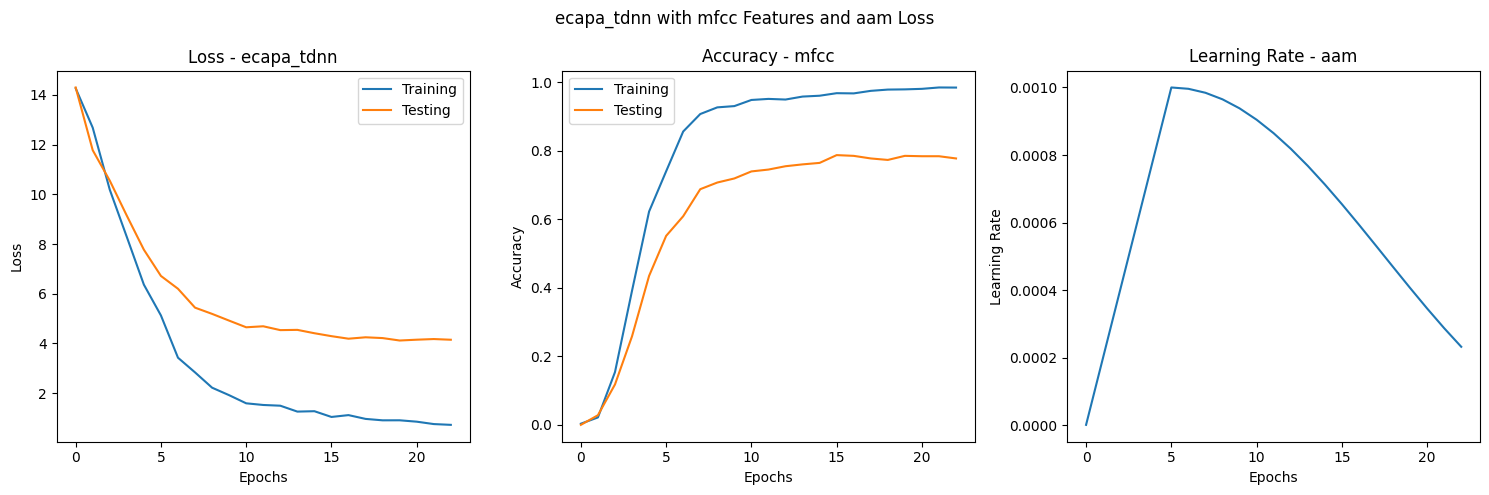

模型 ecapa_tdnn 训练完成！


In [8]:
import os
import time
import datetime
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

class TrainingLogger:
    def __init__(self, log_dir='logs', model_type=None, feature_type=None, criterion_name=None):
        # 创建日志目录
        os.makedirs(log_dir, exist_ok=True)
        
        # 加入时间戳和实验信息
        timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        
        # 构建包含实验信息的文件夹名称
        folder_name = timestamp
        if model_type:
            folder_name += f"_{model_type}"
        if feature_type:
            folder_name += f"_{feature_type}"
        if criterion_name:
            folder_name += f"_{criterion_name}"
            
        self.log_dir = os.path.join(log_dir, folder_name)
        os.makedirs(self.log_dir, exist_ok=True)
        
        # 初始化日志
        self.logs = {
            'train_loss': [],
            'train_acc': [],
            'test_loss': [],
            'test_acc': [],
            'lr': [],
            'epoch_time': []
        }
        
        # 初始化配置
        self.config = {}
        
        # 保存实验信息
        self.model_type = model_type
        self.feature_type = feature_type
        self.criterion_name = criterion_name
        
    def log_config(self, config):
        """记录训练配置"""
        self.config = config
        config_path = os.path.join(self.log_dir, 'config.txt')
        with open(config_path, 'w') as f:
            f.write(f"模型类型: {self.model_type}\n")
            f.write(f"特征类型: {self.feature_type}\n")
            f.write(f"损失函数: {self.criterion_name}\n")
            f.write("-" * 50 + "\n")
            for key, value in config.items():
                f.write(f"{key}: {value}\n")
    
    def log_epoch(self, epoch_stats):
        """记录每个epoch的统计信息"""
        for key, value in epoch_stats.items():
            if key in self.logs:
                self.logs[key].append(value)
        
        # 保存最新日志
        log_path = os.path.join(self.log_dir, 'training_log.txt')
        with open(log_path, 'a') as f:
            f.write(f"Epoch {len(self.logs['train_loss'])}: ")
            for key, value in epoch_stats.items():
                if key in self.logs:
                    f.write(f"{key}={value:.4f} ")
            f.write("\n")
    
    def save_model(self, model, filename):
        """保存模型"""
        model_path = os.path.join(self.log_dir, filename)
        torch.save(model.state_dict(), model_path)
        print(f"模型已保存到 {model_path}")
    
    def plot_training_curves(self):
        """绘制训练曲线"""
        epochs = range(1, len(self.logs['train_loss']) + 1)
        
        # 绘制损失曲线
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.logs['train_loss'], 'b-', label='Training Loss')
        plt.plot(epochs, self.logs['test_loss'], 'r-', label='Validation Loss')
        plt.title(f'Loss Curve - {self.model_type} with {self.criterion_name}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        
        # 绘制准确率曲线
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.logs['train_acc'], 'b-', label='Training Accuracy')
        plt.plot(epochs, self.logs['test_acc'], 'r-', label='Validation Accuracy')
        plt.title(f'Accuracy Curve - {self.feature_type} Features')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.log_dir, 'training_curves.png'))
        plt.close()
        
        # 绘制学习率曲线
        plt.figure(figsize=(6, 4))
        plt.plot(epochs, self.logs['lr'], 'g-')
        plt.title('Learning Rate Schedule')
        plt.xlabel('Epochs')
        plt.ylabel('Learning Rate')
        plt.savefig(os.path.join(self.log_dir, 'lr_schedule.png'))
        plt.close()
        
    def save_confusion_matrix(self, cm, class_names=None):
        """保存混淆矩阵图"""
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix - {self.model_type} ({self.feature_type})')
        plt.savefig(os.path.join(self.log_dir, 'confusion_matrix.png'))
        plt.close()
    
    def save_summary(self, best_acc, total_time):
        """保存训练摘要信息"""
        summary_path = os.path.join(self.log_dir, 'summary.txt')
        with open(summary_path, 'w') as f:
            f.write(f"模型: {self.model_type}\n")
            f.write(f"特征: {self.feature_type}\n")
            f.write(f"损失函数: {self.criterion_name}\n")
            f.write("-" * 50 + "\n")
            f.write(f"训练轮数: {len(self.logs['train_loss'])}\n")
            f.write(f"总训练时间: {total_time:.2f} 秒\n")
            f.write(f"最佳准确率: {best_acc:.4f}\n")
            
            # 添加最后一轮的统计数据
            if len(self.logs['train_loss']) > 0:
                f.write("-" * 50 + "\n")
                f.write("最后一轮统计:\n")
                f.write(f"训练损失: {self.logs['train_loss'][-1]:.4f}\n")
                f.write(f"训练准确率: {self.logs['train_acc'][-1]:.4f}\n")
                f.write(f"测试损失: {self.logs['test_loss'][-1]:.4f}\n")
                f.write(f"测试准确率: {self.logs['test_acc'][-1]:.4f}\n")

def train_model(model, train_loader, test_loader, criterion_name='ce', optimizer=None, 
                n_epochs=30, device='cuda', patience=7, warmup_epochs=5, logger=None):
    """
    训练模型
    Args:
        model: 模型实例
        train_loader: 训练数据加载器
        test_loader: 测试数据加载器
        criterion_name: 损失函数名称，'ce'(交叉熵), 'aam'(AAM损失), 'sphereface2'(SphereFace2损失)
        optimizer: 优化器
        n_epochs: 总训练轮数
        device: 训练设备
        patience: 早停的patience
        warmup_epochs: 预热轮数
        logger: 训练日志记录器
    Returns:
        训练历史
    """
    model.to(device)
    
    # 选择损失函数
    if criterion_name == 'ce':
        criterion = nn.CrossEntropyLoss()
    elif criterion_name == 'aam':
        criterion = AAMLoss(margin=0.2, scale=30.0, eps=1e-7)
        # 确保classifier可用于损失函数计算
        if not hasattr(criterion, 'classifier') and hasattr(model, 'classifier'):
            criterion.classifier = model.classifier
    elif criterion_name == 'sphereface2':
        n_speakers = train_loader.dataset.get_n_speakers()
        criterion = SphereFace2Loss(n_classes=n_speakers)
        # 将SphereFace2Loss的权重移至正确设备
        criterion = criterion.to(device)
    else:
        raise ValueError(f"不支持的损失函数: {criterion_name}")
    
    # 初始化优化器
    if optimizer is None:
        # 基于模型和损失函数选择不同的学习率
        if model.__class__.__name__ in ['CAMPPlus', 'TDNN'] or criterion_name == 'aam':
            lr = 0.0001  # 对复杂模型和AAM损失降低学习率
        else:
            lr = 0.001
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    # 学习率调度器
    scheduler = WarmupCosineSchedulerLR(
        optimizer, 
        warmup_epochs=warmup_epochs,
        max_epochs=n_epochs,
        warmup_start_lr=1e-6,
        eta_min=1e-7
    )
    
    # 混合精度训练
    scaler = torch.cuda.amp.GradScaler()
    # 对某些模型禁用混合精度
    use_amp = model.__class__.__name__ not in ['CAMPPlus']
    
    # 初始化日志记录器
    if logger is None:
        logger = TrainingLogger(model_type=model.__class__.__name__,
                               feature_type=train_loader.dataset.feature_type,
                               criterion_name=criterion_name)
    
    # 记录配置
    config = {
        'criterion': criterion_name,
        'optimizer': optimizer.__class__.__name__,
        'learning_rate': optimizer.param_groups[0]['lr'],
        'batch_size': train_loader.batch_size,
        'epochs': n_epochs,
        'warmup_epochs': warmup_epochs,
        'patience': patience,
        'feature_type': train_loader.dataset.feature_type,
        'model': model.__class__.__name__,
        'use_amp': use_amp
    }
    logger.log_config(config)
    
    best_acc = 0
    patience_counter = 0
    nan_batches_count = 0
    
    for epoch in range(n_epochs):
        epoch_start_time = time.time()
        
        # 训练阶段
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{n_epochs} [Train]')
        
        for features, labels in train_pbar:
            features, labels = features.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # 检查特征
            if torch.isnan(features).any():
                print("警告：检测到输入特征中有NaN值")
                nan_batches_count += 1
                if nan_batches_count > 5:
                    print("连续出现多个NaN批次，训练可能不稳定")
                continue
            
            if use_amp:
                # 使用混合精度训练
                with torch.cuda.amp.autocast():
                    outputs = model(features)
                    
                    # 在损失计算前检查输出
                    if torch.isnan(outputs['features']).any() or torch.isnan(outputs['logits']).any():
                        print("警告：模型输出包含NaN")
                        nan_batches_count += 1
                        continue
                    
                    if criterion_name == 'aam':
                        loss = criterion(outputs, labels)
                    elif criterion_name == 'sphereface2':
                        loss = criterion(outputs['features'], labels)
                    else:
                        loss = criterion(outputs['logits'], labels)
                    
                    # 检查损失是否为NaN
                    if torch.isnan(loss):
                        print("警告：损失为NaN，跳过此批次")
                        nan_batches_count += 1
                        continue
                
                scaler.scale(loss).backward()
                # 移除梯度裁剪行
                scaler.step(optimizer)
                scaler.update()
            else:
                # 不使用混合精度
                outputs = model(features)
                
                # 在损失计算前检查输出
                if torch.isnan(outputs['features']).any() or torch.isnan(outputs['logits']).any():
                    print("警告：模型输出包含NaN")
                    nan_batches_count += 1
                    continue
                
                if criterion_name == 'aam':
                    loss = criterion(outputs, labels)
                elif criterion_name == 'sphereface2':
                    loss = criterion(outputs['features'], labels)
                else:
                    loss = criterion(outputs['logits'], labels)
                
                # 检查损失是否为NaN
                if torch.isnan(loss):
                    print("警告：损失为NaN，跳过此批次")
                    nan_batches_count += 1
                    continue
                
                loss.backward()
                # 移除梯度裁剪行
                optimizer.step()
            
            # 重置NaN计数器
            nan_batches_count = 0
            
            # 记录训练数据
            train_loss += loss.item()
            _, predicted = torch.max(outputs['logits'].data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            current_loss = train_loss / (train_pbar.n + 1)
            current_acc = train_correct / train_total
            train_pbar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'acc': f'{current_acc:.4f}'
            })
        
        # 如果训练一个epoch全是NaN批次
        if train_total == 0:
            print("警告：整个训练epoch都为NaN，尝试降低学习率或检查模型")
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.5
            continue
        
        train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        
        # 测试阶段
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        test_pbar = tqdm(test_loader, desc=f'Epoch {epoch+1}/{n_epochs} [Test]')
        
        with torch.no_grad():
            for features, labels in test_pbar:
                features, labels = features.to(device), labels.to(device)
                
                # 检查特征
                if torch.isnan(features).any():
                    print("警告：测试集中检测到NaN特征")
                    continue
                
                outputs = model(features)
                
                # 检查输出
                if torch.isnan(outputs['features']).any() or torch.isnan(outputs['logits']).any():
                    print("警告：测试中模型输出包含NaN")
                    continue
                
                if criterion_name == 'aam':
                    loss = criterion(outputs, labels)
                elif criterion_name == 'sphereface2':
                    loss = criterion(outputs['features'], labels)
                else:
                    loss = criterion(outputs['logits'], labels)
                
                # 检查损失是否为NaN
                if torch.isnan(loss):
                    print("警告：测试损失为NaN，跳过此批次")
                    continue
                
                test_loss += loss.item()
                _, predicted = torch.max(outputs['logits'].data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
                
                current_loss = test_loss / (test_pbar.n + 1)
                current_acc = test_correct / test_total
                test_pbar.set_postfix({
                    'loss': f'{current_loss:.4f}',
                    'acc': f'{current_acc:.4f}'
                })
        
        # 如果测试一个epoch全是NaN批次
        if test_total == 0:
            print("警告：整个测试epoch都为NaN，跳过此轮评估")
            test_loss = float('inf')
            test_acc = 0
        else:
            test_loss = test_loss / len(test_loader)
            test_acc = test_correct / test_total
        
        # 更新学习率
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()
        
        # 记录本轮训练结果
        epoch_time = time.time() - epoch_start_time
        epoch_stats = {
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'lr': current_lr,
            'epoch_time': epoch_time
        }
        logger.log_epoch(epoch_stats)
        
        print(f'\n轮次 {epoch+1}/{n_epochs}:')
        print(f'训练损失: {train_loss:.4f}, 训练准确率: {train_acc:.4f}')
        print(f'测试损失: {test_loss:.4f}, 测试准确率: {test_acc:.4f}')
        print(f'学习率: {current_lr:.6f}, 用时: {epoch_time:.2f}秒')
        print('-' * 50)
        
        # 早停检查
        if test_acc > best_acc:
            best_acc = test_acc
            patience_counter = 0
            # 保存最佳模型
            logger.save_model(model, 'best_model.pth')
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f'在轮次 {epoch+1} 提前停止训练')
            break
    
    # 训练结束，绘制训练曲线
    logger.plot_training_curves()
    
    # 保存最终模型
    logger.save_model(model, 'final_model.pth')
    
    return logger.logs

# 创建数据加载器
batch_size = 32
# 选择特征类型
feature_type = 'mfcc'  # 可选: 'mfcc', 'fbank', 'wav2vec2'

# 设置wav2vec2模型的本地路径（如果使用wav2vec2特征）
model_path = "/home/chihan/workspace/speech_process/model/wav2vec2-base-960h"

print(f"\n使用 {feature_type} 特征进行训练...")
train_dataset = SpeakerDataset(train_files, 
                              feature_type=feature_type, 
                              augment=True,
                              model_path=model_path if feature_type == 'wav2vec2' else None)

test_dataset = SpeakerDataset(test_files, 
                             feature_type=feature_type, 
                             augment=False,
                             model_path=model_path if feature_type == 'wav2vec2' else None)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 获取特征大小
if feature_type == 'mfcc':
    input_size = 40
elif feature_type == 'fbank':
    input_size = 80
elif feature_type == 'wav2vec2':
    input_size = 768  # wav2vec2输出特征维度

# 获取说话者数量
n_speakers = train_dataset.get_n_speakers()

# 模型配置
model_type = "ecapa_tdnn"  # 可选: 'ecapa_tdnn', 'tdnn', 'camp_plus'
criterion_name = 'aam'  # 'ce', 'aam', 或 'sphereface2'

# 根据所选模型类型设置相应的默认配置
if model_type == "ecapa_tdnn":
    print(f"使用 ECAPA-TDNN 模型进行训练")
    channels = 512
    embd_dim = 192
    model = EcapaTDNN(
        input_size=input_size, 
        channels=channels, 
        embd_dim=embd_dim,
        n_speakers=n_speakers,
        feature_type=feature_type
    )
elif model_type == "tdnn":
    print(f"使用 TDNN 模型进行训练")
    channels = 512
    embd_dim = 192
    model = TDNN(
        input_size=input_size, 
        channels=channels, 
        embd_dim=embd_dim,
        n_speakers=n_speakers,
        feature_type=feature_type
    )
elif model_type == "camp_plus":
    print(f"使用 CAMPPlus 模型进行训练")
    embd_dim = 192
    model = CAMPPlus(
        input_size=input_size,
        embd_dim=embd_dim,
        growth_rate=16,  # 降低复杂度
        bn_size=4,
        init_channels=64,  # 降低初始通道数
        n_speakers=n_speakers,
        feature_type=feature_type
    )
else:
    raise ValueError(f"不支持的模型类型: {model_type}")

# 选择损失函数
print(f"使用损失函数: {criterion_name}")

lr = 0.001  # 对复杂模型和AAM损失降低学习率
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

# 训练配置
n_epochs = 30    # 训练轮数 
patience = 7      # 早停耐心值
warmup_epochs = 5 # 预热轮数

# 初始化日志记录器
logger = TrainingLogger(
    log_dir='logs', 
    model_type=model_type,
    feature_type=feature_type,
    criterion_name=criterion_name
)

# 训练模型
total_start_time = time.time()
print(f"开始训练模型: {model_type} (特征: {feature_type}, 损失: {criterion_name})...")
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion_name=criterion_name,
    optimizer=optimizer,
    n_epochs=n_epochs,
    device=device,
    patience=patience,
    warmup_epochs=warmup_epochs,
    logger=logger
)
total_training_time = time.time() - total_start_time

# 保存训练摘要
best_acc = max(history['test_acc']) if 'test_acc' in history and history['test_acc'] else 0
logger.save_summary(best_acc, total_training_time)

# 显示训练历史
plt.figure(figsize=(15, 5))

# 设置matplotlib使用英文字体，避免中文乱码
plt.rcParams.update({
    'font.sans-serif': ['Arial'],
    'axes.unicode_minus': True,
    'font.family': 'sans-serif'
})

plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Training')
plt.plot(history['test_loss'], label='Testing')
plt.title(f'Loss - {model_type}')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Training')
plt.plot(history['test_acc'], label='Testing')
plt.title(f'Accuracy - {feature_type}')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['lr'])
plt.title(f'Learning Rate - {criterion_name}')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')

plt.suptitle(f'{model_type} with {feature_type} Features and {criterion_name} Loss')
plt.tight_layout()
plt.savefig(f'training_history_{model_type}_{feature_type}_{criterion_name}.png')
plt.show()

print(f"模型 {model_type} 训练完成！")

## 5. 评价指标(准确率Accuracy)

正在评估模型...


提取注册音频特征:   0%|          | 0/102 [00:00<?, ?it/s]

提取测试音频特征: 100%|██████████| 29/29 [00:08<00:00,  3.52it/s]


计算相似度得分...


计算相似度: 100%|██████████| 924/924 [00:01<00:00, 496.40it/s]



等错误率(EER): 0.0684
最小检测代价(MinDCF): 0.0066
最佳阈值准确率: 0.9316
EER阈值: 0.2457


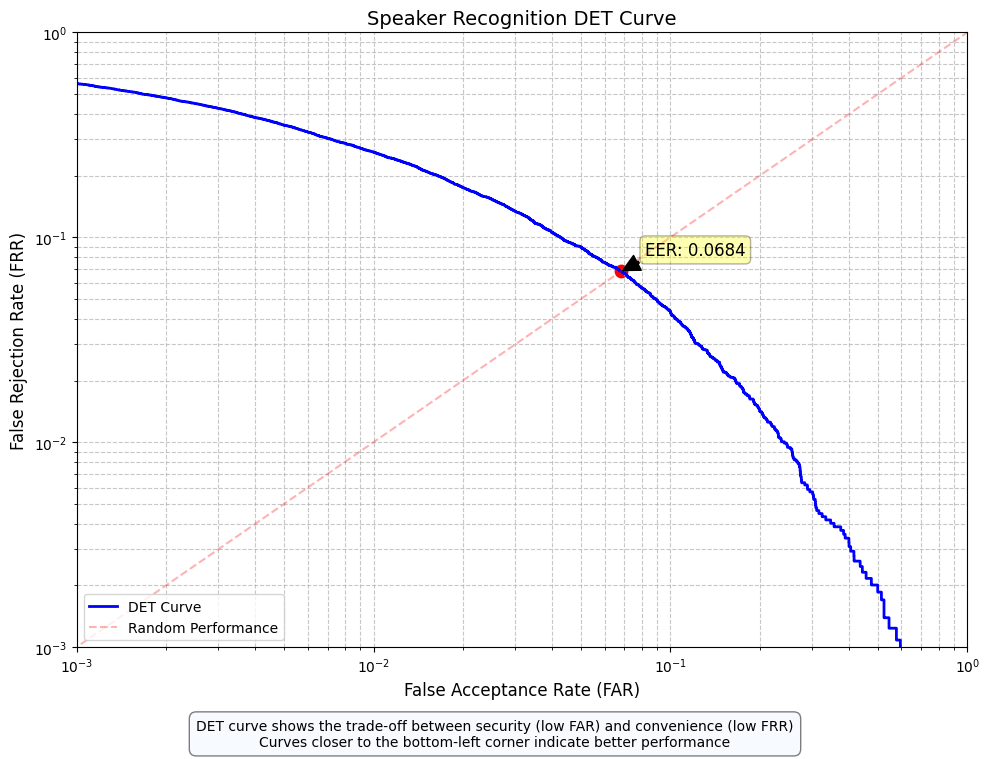

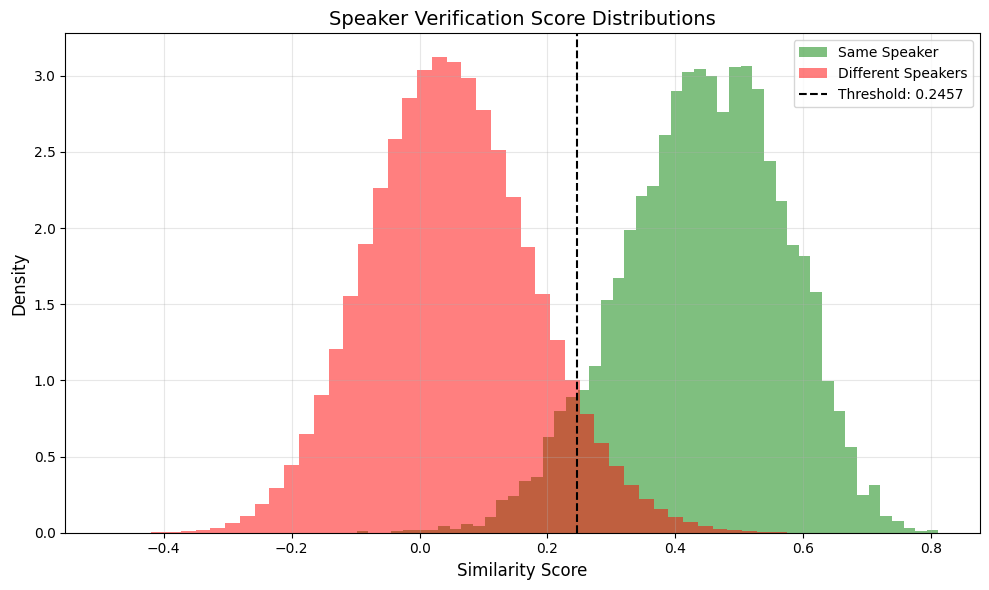

In [14]:
## 评价指标(准确率Accuracy、EER、MinDCF)
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

def compute_eer(fpr, fnr):
    """简化且稳健的EER计算"""
    # 查找FPR和FNR最接近的点
    idx = np.argmin(np.abs(fpr - fnr))
    # 取平均值作为EER (更稳定)
    eer = (fpr[idx] + fnr[idx]) / 2
    # 找到对应阈值
    return eer, idx

def compute_min_dcf(far, frr, thresholds, p_target=0.01, c_miss=1, c_fa=1):
    """计算MinDCF (Minimum Detection Cost Function)"""
    dcf = c_miss * p_target * frr + c_fa * (1 - p_target) * far
    min_dcf = np.min(dcf)
    min_dcf_threshold = thresholds[np.argmin(dcf)]
    return min_dcf, min_dcf_threshold

def evaluate_model(model, enroll_loader, test_loader, device):
    """评估模型性能 - 使用一对一验证方式"""
    model.eval()
    
    # 1. 提取注册集的声纹特征和标签
    enroll_features, enroll_labels = [], []
    with torch.no_grad():
        for features, labels in tqdm(enroll_loader, desc="提取注册音频特征"):
            features = features.to(device)
            outputs = model(features)
            # 获取特征向量，不是logits
            feature_vecs = outputs['features'].cpu().numpy()
            enroll_features.extend(feature_vecs)
            enroll_labels.extend(labels.cpu().numpy())
    
    enroll_features = np.array(enroll_features)
    enroll_labels = np.array(enroll_labels)
    
    # 2. 提取测试集的声纹特征和标签
    test_features, test_labels = [], []
    with torch.no_grad():
        for features, labels in tqdm(test_loader, desc="提取测试音频特征"):
            features = features.to(device)
            outputs = model(features)
            feature_vecs = outputs['features'].cpu().numpy()
            test_features.extend(feature_vecs)
            test_labels.extend(labels.cpu().numpy())
    
    test_features = np.array(test_features)
    test_labels = np.array(test_labels)
    
    # 3. 计算余弦相似度得分
    print("计算相似度得分...")
    all_scores = []
    all_labels = []
    
    for i, test_feat in enumerate(tqdm(test_features, desc="计算相似度")):
        # L2归一化
        test_feat_norm = test_feat / np.linalg.norm(test_feat)
        enroll_feat_norm = enroll_features / np.linalg.norm(enroll_features, axis=1, keepdims=True)
        
        # 计算余弦相似度
        similarity = np.dot(enroll_feat_norm, test_feat_norm)
        
        # 生成真实标签：1表示同一说话人，0表示不同说话人
        true_labels = (enroll_labels == test_labels[i]).astype(int)
        
        all_scores.extend(similarity)
        all_labels.extend(true_labels)
    
    # 4. 计算ROC曲线和性能指标
    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)
    
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
    fnr = 1 - tpr  # 假拒率 = 1 - 真接受率
    
    # 计算EER
    eer, idx = compute_eer(fpr, fnr)
    eer_threshold = thresholds[idx]
    
    # 计算MinDCF
    min_dcf, _ = compute_min_dcf(fpr, fnr, thresholds)
    
    # 5. 使用最佳阈值计算准确率
    if eer_threshold is not None:
        predictions = (all_scores >= eer_threshold).astype(int)
        accuracy = accuracy_score(all_labels, predictions)
    else:
        accuracy = None
    
    return {
        'accuracy': accuracy,
        'eer': eer,
        'min_dcf': min_dcf,
        'fpr': fpr,
        'fnr': fnr,
        'thresholds': thresholds,
        'all_scores': all_scores,
        'all_labels': all_labels,
        'eer_threshold': eer_threshold
    }

def plot_det_curve(fpr, fnr, eer, title='Speaker Recognition DET Curve'):
    """正确绘制DET曲线"""
    # 设置matplotlib使用通用字体，避免字体警告
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'FreeSans', 'sans-serif']
    
    plt.figure(figsize=(10, 8))
    
    # 绘制DET曲线
    plt.plot(fpr, fnr, 'b-', linewidth=2, label='DET Curve')
    
    # 标记EER点
    idx = np.nanargmin(np.absolute(fnr - fpr))
    plt.scatter(fpr[idx], fnr[idx], s=80, c='red', marker='o')
    plt.annotate(f'EER: {eer:.4f}', 
                 xy=(fpr[idx], fnr[idx]),
                 xytext=(max(0.02, fpr[idx]*1.2), max(0.02, fnr[idx]*1.2)),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
                 fontsize=12,
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))
    
    # 使用对数坐标以更好地展示低错误率区域
    plt.yscale('log')
    plt.xscale('log')
    
    # 设置轴边界，避免空白区域
    plt.xlim([0.001, 1.0])
    plt.ylim([0.001, 1.0])
    
    # 添加网格和参考线
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='Random Performance')  # 对角线参考
    
    plt.xlabel('False Acceptance Rate (FAR)', fontsize=12)
    plt.ylabel('False Rejection Rate (FRR)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='lower left', fontsize=10)
    
    # 添加DET曲线解释
    plt.figtext(0.5, 0.01, 
                "DET curve shows the trade-off between security (low FAR) and convenience (low FRR)\n"
                "Curves closer to the bottom-left corner indicate better performance",
                ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.5", facecolor='aliceblue', alpha=0.5))
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # 为底部说明文字留出空间
    plt.show()

def plot_score_distributions(scores, labels, threshold=None, title='Score Distributions'):
    """绘制得分分布图，显示同一说话人和不同说话人的得分分布"""
    plt.figure(figsize=(10, 6))
    
    # 分离同一说话人和不同说话人的得分
    same_speaker_scores = scores[labels == 1]
    diff_speaker_scores = scores[labels == 0]
    
    # 绘制分布直方图
    plt.hist(same_speaker_scores, bins=50, alpha=0.5, color='green', 
             density=True, label='Same Speaker')
    plt.hist(diff_speaker_scores, bins=50, alpha=0.5, color='red', 
             density=True, label='Different Speakers')
    
    # 如果提供了阈值，则绘制阈值线
    if threshold is not None:
        plt.axvline(x=threshold, color='black', linestyle='--', 
                   label=f'Threshold: {threshold:.4f}')
    
    plt.xlabel('Similarity Score', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 使用方法示例（需根据实际数据加载器调整）
print("正在评估模型...")

# 注意：需要先定义enroll_loader和test_loader
# 这里假设已有相应的加载器，或者使用现有测试集分割成两部分
# 如果没有单独的注册集，可以将训练集作为注册集
enroll_loader = train_loader  # 或使用专门的注册集

metrics = evaluate_model(model, enroll_loader, test_loader, device)

# 打印评估结果
print(f"\n等错误率(EER): {metrics['eer']:.4f}")
print(f"最小检测代价(MinDCF): {metrics['min_dcf']:.4f}")
if metrics['accuracy'] is not None:
    print(f"最佳阈值准确率: {metrics['accuracy']:.4f}")
print(f"EER阈值: {metrics['eer_threshold']:.4f}")

# 绘制DET曲线
plot_det_curve(metrics['fpr'], metrics['fnr'], metrics['eer'])

# 绘制得分分布
plot_score_distributions(
    metrics['all_scores'], 
    metrics['all_labels'], 
    metrics['eer_threshold'],
    title='Speaker Verification Score Distributions'
)

##  6. 分析和可视化

In [ ]:
## 请使用matplotlib等可视化库对你的实验结果进行可视化分析。
## 包括但不限于准确率的对比、错误分类的分析、特征的影响等。
#

## 7. 结果讨论
讨论你的模型性能，尝试解释为什么某些模型比其他模型表现好，以及可能的改进方法。

## 8. 保存模型（可选）
如果需要，可以在这里添加代码保存你的模型。